# Performance Analysis (Sports)

This notebook loads Sports-only inference profiling artifacts for RPG and SASRec from both the shared group artifacts tree and repo-local artifacts. It summarizes the latest available profiling session for each model and creates merged scaling plots for candidate-pool size versus inference time and CUDA runtime memory.

Expected layouts:

```text
<artifact-root>/<model>/perf/sports/<session>/manifest.json
<artifact-root>/<model>/perf/sports/<session>/summaries/profile_summary.csv
<artifact-root>/rpg/perf/sports/<session>/graphs/validate_graph_report.json
```

RPG graph-validation reports are still shown when available; SASRec uses full-sort scoring and has no graph-build phase.


In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ROOT = Path.cwd().resolve()
while ROOT.name not in {"RPG", "RPG-uva"} and ROOT.parent != ROOT:
    ROOT = ROOT.parent

ARTIFACT_SOURCES = [
    {"model": "RPG", "root": Path("/projects/prjs2120/groups/group_16/artifacts/rpg/perf/sports")},
    {"model": "RPG", "root": ROOT / "artifacts" / "rpg" / "perf" / "sports"},
    {"model": "SASRec", "root": Path("/projects/prjs2120/groups/group_16/artifacts/sasrec/perf/sports")},
    {"model": "SASRec", "root": ROOT / "artifacts" / "sasrec" / "perf" / "sports"},
]

MODEL_ORDER = ["RPG", "SASRec"]
PLOT_COLORS = {"RPG": "#355C7D", "SASRec": "#2A9D8F"}


In [4]:
def _read_json(path: Path):
    return json.loads(path.read_text())


def _safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.is_file() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)


def _decorate_frame(frame: pd.DataFrame, **metadata) -> pd.DataFrame:
    if frame.empty:
        return frame
    result = frame.copy()
    for key, value in metadata.items():
        result[key] = value
    return result


def _model_rank(value: str) -> int:
    return MODEL_ORDER.index(value) if value in MODEL_ORDER else len(MODEL_ORDER)


def load_perf_artifacts():
    manifest_rows = []
    summary_frames = []
    graph_frames = []
    validation_rows = []
    validation_graph_rows = []

    for source in ARTIFACT_SOURCES:
        artifact_root = source["root"]
        source_model = source["model"]
        if not artifact_root.exists():
            continue

        for manifest_path in sorted(artifact_root.rglob("manifest.json")):
            session_root = manifest_path.parent.resolve()
            payload = _read_json(manifest_path)
            summary_path = Path(payload.get("summary_csv", session_root / "summaries" / "profile_summary.csv"))
            raw_path = Path(payload.get("raw_csv", session_root / "raw" / "profile_runs.csv"))
            graph_path = Path(payload.get("graph_csv", session_root / "graphs" / "graph_builds.csv"))

            manifest_rows.append(
                {
                    "model": source_model,
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "manifest_path": str(manifest_path),
                    "summary_path": str(summary_path),
                    "raw_path": str(raw_path),
                    "graph_path": str(graph_path),
                    "has_summary_csv": summary_path.is_file(),
                    "has_raw_csv": raw_path.is_file(),
                    "has_graph_csv": graph_path.is_file(),
                }
            )

            summary_df = _safe_read_csv(summary_path)
            if not summary_df.empty and "method" in summary_df.columns:
                summary_df = summary_df.copy()
                summary_df["method"] = summary_df["method"].replace({"RPG": "RPG", "SASRec": "SASRec"})
            summary_frames.append(
                _decorate_frame(
                    summary_df,
                    model=source_model,
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    summary_path=str(summary_path),
                    raw_path=str(raw_path),
                    graph_path=str(graph_path),
                )
            )

            graph_df = _safe_read_csv(graph_path)
            graph_frames.append(
                _decorate_frame(
                    graph_df,
                    model=source_model,
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    graph_path=str(graph_path),
                )
            )

        if source_model != "RPG":
            continue
        for report_path in sorted(artifact_root.rglob("validate_graph_report.json")):
            session_root = report_path.parents[1].resolve()
            payload = _read_json(report_path)
            comparisons = payload.get("comparisons", {})
            validation_rows.append(
                {
                    "model": source_model,
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "report_path": str(report_path),
                    "paper_md_path": str(report_path.with_name("paper.md")),
                    "checkpoint_path": payload.get("checkpoint_path"),
                    "checkpoint_name": None if payload.get("checkpoint_path") is None else Path(payload["checkpoint_path"]).name,
                    "checkpoint_signature": payload.get("checkpoint_signature"),
                    "pool_size": payload.get("pool_size"),
                    "topk": payload.get("topk"),
                    "dense_vs_flat_mean_overlap": comparisons.get("dense_vs_flat", {}).get("mean_overlap_rate"),
                    "dense_vs_flat_exact_match_rate": comparisons.get("dense_vs_flat", {}).get("exact_match_rate"),
                    "flat_vs_hnsw_mean_overlap": comparisons.get("flat_vs_hnsw", {}).get("mean_overlap_rate"),
                    "flat_vs_hnsw_p50_overlap": comparisons.get("flat_vs_hnsw", {}).get("p50_overlap_rate"),
                    "dense_vs_hnsw_mean_overlap": comparisons.get("dense_vs_hnsw", {}).get("mean_overlap_rate"),
                    "dense_vs_hnsw_p50_overlap": comparisons.get("dense_vs_hnsw", {}).get("p50_overlap_rate"),
                }
            )
            for graph_record in payload.get("graph_records", []):
                validation_graph_rows.append(
                    {
                        "model": source_model,
                        "artifact_root": str(artifact_root),
                        "session": session_root.name,
                        "session_root": str(session_root),
                        "report_path": str(report_path),
                        **graph_record,
                    }
                )

    manifest_index = pd.DataFrame(manifest_rows)
    if not manifest_index.empty:
        manifest_index = manifest_index.sort_values(["model", "session", "artifact_root"]).reset_index(drop=True)
    profile_summaries = pd.concat([frame for frame in summary_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in summary_frames) else pd.DataFrame()
    graph_builds = pd.concat([frame for frame in graph_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in graph_frames) else pd.DataFrame()
    validation_runs = pd.DataFrame(validation_rows)
    validation_graphs = pd.DataFrame(validation_graph_rows)
    return manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs


In [5]:
manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs = load_perf_artifacts()

existing_roots = [f"{source['model']}: {source['root']}" for source in ARTIFACT_SOURCES if source["root"].exists()]
print(
    f"Discovered {len(manifest_index)} profiling sessions and {len(validation_runs)} validation reports across {len(existing_roots)} artifact roots."
)
if existing_roots:
    print("Existing artifact roots:")
    for root in existing_roots:
        print(f"  - {root}")

if manifest_index.empty:
    print("No manifest.json files found under the configured perf artifact roots.")
else:
    display(
        manifest_index[
            [
                "model",
                "session",
                "artifact_root",
                "has_summary_csv",
                "has_raw_csv",
                "has_graph_csv",
                "summary_path",
            ]
        ].sort_values(["model", "session", "artifact_root"], ascending=[True, False, True]).reset_index(drop=True)
    )


Discovered 2 profiling sessions and 1 validation reports across 2 artifact roots.
Existing artifact roots:
  - RPG: /gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports
  - SASRec: /gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports


,model,session,artifact_root,has_summary_csv,has_raw_csv,has_graph_csv,summary_path
0,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,True,True,True,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...
1,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf...,True,True,False,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf...


## Latest Profiling Sessions

This table keeps the latest discovered profiling session per model and shows the per-pool median latency, CUDA memory, traversal, and `NDCG@10` measurements.


In [6]:
if profile_summaries.empty:
    print("No profile summary rows available.")
    latest_profile_rows = pd.DataFrame()
else:
    latest_sessions = (
        profile_summaries[["model", "artifact_root", "session", "session_root"]]
        .drop_duplicates()
        .sort_values(["model", "session", "artifact_root"])
        .groupby("model", as_index=False)
        .tail(1)
    )
    latest_profile_rows = profile_summaries.merge(
        latest_sessions[["model", "session_root"]],
        on=["model", "session_root"],
        how="inner",
    ).sort_values(["model", "pool_size"]).reset_index(drop=True)

    display_columns = [
        "model",
        "session",
        "artifact_root",
        "pool_size",
        "graph_backend",
        "epoch_time_s_median",
        "peak_cuda_runtime_delta_allocated_gb_median",
        "peak_cuda_allocated_gb_median",
        "visited_ratio_median",
        "n_visited_items_median",
        "ndcg_at_10_median",
        "checkpoint_signature",
    ]
    existing_columns = [column for column in display_columns if column in latest_profile_rows.columns]
    display(
        latest_profile_rows[existing_columns].style.format(
            {
                "epoch_time_s_median": "{:.2f}",
                "peak_cuda_runtime_delta_allocated_gb_median": "{:.3f}",
                "peak_cuda_allocated_gb_median": "{:.3f}",
                "visited_ratio_median": "{:.4f}",
                "n_visited_items_median": "{:.1f}",
                "ndcg_at_10_median": "{:.5f}",
            }
        )
    )

    if not graph_builds.empty:
        latest_graph_rows = graph_builds.merge(
            latest_sessions[["model", "session_root"]],
            on=["model", "session_root"],
            how="inner",
        ).sort_values(["model", "pool_size"]).reset_index(drop=True)
        if not latest_graph_rows.empty:
            display(Markdown("### RPG graph-build rows"))
            display(latest_graph_rows)


,model,session,artifact_root,pool_size,graph_backend,epoch_time_s_median,peak_cuda_runtime_delta_allocated_gb_median,peak_cuda_allocated_gb_median,visited_ratio_median,n_visited_items_median,ndcg_at_10_median,checkpoint_signature
0,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,20000,hnsw,37.23,0.103,0.197,0.0798,1595.8,0.01755,783be92f6501
1,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,50000,hnsw,36.30,0.104,0.221,0.0256,1277.6,0.00564,783be92f6501
2,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,100000,hnsw,34.46,0.103,0.265,0.0113,1132.7,0.00173,783be92f6501
3,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,200000,hnsw,34.34,0.104,0.352,0.0053,1066.9,0.00049,783be92f6501
4,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,500000,hnsw,33.64,0.104,0.612,0.0021,1040.3,0.00014,783be92f6501
5,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports,20000,full_sort,6.56,0.040,0.053,1.0000,20000.0,0.01484,e2f7b1220dbe
6,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports,50000,full_sort,13.30,0.051,0.071,1.0000,50000.0,0.00638,e2f7b1220dbe
7,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports,100000,full_sort,23.37,0.099,0.131,1.0000,100000.0,0.00226,e2f7b1220dbe
8,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports,200000,full_sort,42.89,0.195,0.251,1.0000,200000.0,0.00033,e2f7b1220dbe
9,SASRec,20260611T184947961897Z_job23689390,/gpfs/home6/scur1202/RPG/artifacts/sasrec/perf/sports,500000,full_sort,112.57,0.480,0.608,1.0000,500000.0,0.00005,e2f7b1220dbe


### RPG graph-build rows

,cache_id,adjacency_path,metadata_path,backend,pool_size,topk,vector_batch_size,build_seconds,loaded_from_cache,checkpoint_signature,model,artifact_root,session,session_root,manifest_path,graph_path
0,rpg_sports_and_outdoors_pool20000_backend-hnsw...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,20000,100,512,84.085703,True,783be92f6501,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...
1,rpg_sports_and_outdoors_pool50000_backend-hnsw...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,50000,100,512,288.902416,True,783be92f6501,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...
2,rpg_sports_and_outdoors_pool100000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,100000,100,512,509.885182,True,783be92f6501,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...
3,rpg_sports_and_outdoors_pool200000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,200000,100,512,932.074320,True,783be92f6501,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...
4,rpg_sports_and_outdoors_pool500000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,500000,100,512,1668.942545,True,783be92f6501,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...


## Merged Paper-Style Scaling Plots

These plots compare the latest RPG and SASRec Sports profiling sessions. Runtime CUDA delta is the paper-faithful memory metric because it subtracts the already-loaded model/graph/embedding baseline.


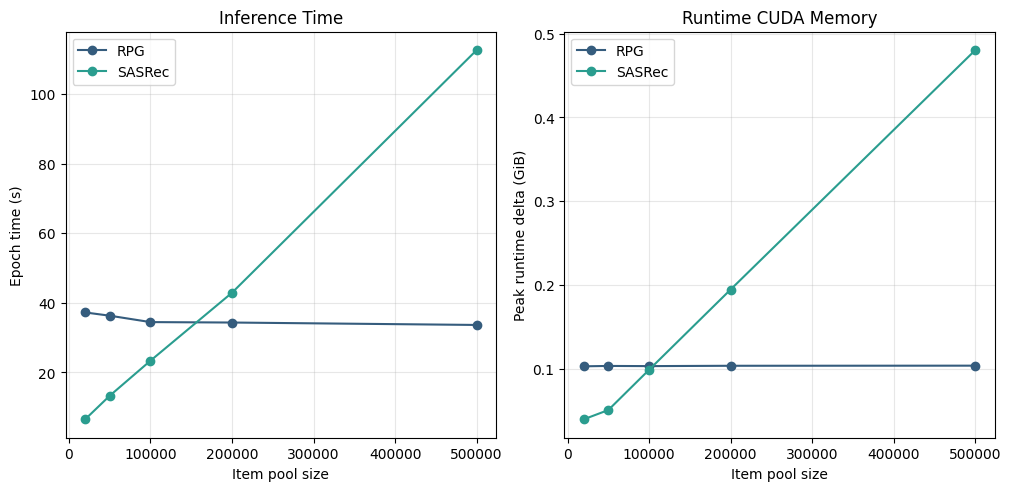

In [12]:
if profile_summaries.empty or latest_profile_rows.empty:
    print("No profiling rows available for plotting.")
else:
    plot_rows = latest_profile_rows.sort_values(["model", "pool_size"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)

    for model, frame in plot_rows.groupby("model"):
        frame = frame.sort_values("pool_size")
        color = PLOT_COLORS.get(model)
        axes[0].plot(frame["pool_size"], frame["epoch_time_s_median"], marker="o", label=model, color=color)
        axes[1].plot(
            frame["pool_size"],
            frame["peak_cuda_runtime_delta_allocated_gb_median"],
            marker="o",
            label=model,
            color=color,
        )
      
    axes[0].set_title("Inference Time")
    axes[0].set_xlabel("Item pool size")
    axes[0].set_ylabel("Epoch time (s)")
    axes[1].set_title("Runtime CUDA Memory")
    axes[1].set_xlabel("Item pool size")
    axes[1].set_ylabel("Peak runtime delta (GiB)")


    for axis in axes:
        axis.grid(True, alpha=0.3)
        axis.legend()

    plt.show()


## Latest RPG Graph-Validation Report

If an RPG `validate_graph_report.json` session exists, this section shows the latest overlap summary plus the paper-ready text snippet written by the validation job.


In [ ]:
if validation_runs.empty:
    print("No RPG validate_graph_report.json files found.")
else:
    latest_validation = (
        validation_runs.sort_values(["session", "artifact_root"])
        .tail(1)
        .reset_index(drop=True)
    )
    display(
        latest_validation[
            [
                "session",
                "artifact_root",
                "pool_size",
                "topk",
                "checkpoint_signature",
                "dense_vs_flat_mean_overlap",
                "dense_vs_flat_exact_match_rate",
                "flat_vs_hnsw_mean_overlap",
                "flat_vs_hnsw_p50_overlap",
                "dense_vs_hnsw_mean_overlap",
                "dense_vs_hnsw_p50_overlap",
            ]
        ].style.format(
            {
                "dense_vs_flat_mean_overlap": "{:.4%}",
                "dense_vs_flat_exact_match_rate": "{:.4%}",
                "flat_vs_hnsw_mean_overlap": "{:.4%}",
                "flat_vs_hnsw_p50_overlap": "{:.2%}",
                "dense_vs_hnsw_mean_overlap": "{:.4%}",
                "dense_vs_hnsw_p50_overlap": "{:.2%}",
            }
        )
    )

    latest_validation_row = latest_validation.iloc[0]
    latest_validation_graphs = (
        validation_graphs[validation_graphs["session_root"] == latest_validation_row["session_root"]]
        .sort_values("backend")
        .reset_index(drop=True)
    )
    if not latest_validation_graphs.empty:
        display(latest_validation_graphs)

    paper_md_path = Path(latest_validation_row["paper_md_path"])
    if paper_md_path.is_file():
        display(Markdown("### Paper-ready summary"))
        display(Markdown(paper_md_path.read_text()))


,session,artifact_root,pool_size,topk,checkpoint_signature,dense_vs_flat_mean_overlap,dense_vs_flat_exact_match_rate,flat_vs_hnsw_mean_overlap,flat_vs_hnsw_p50_overlap,dense_vs_hnsw_mean_overlap,dense_vs_hnsw_p50_overlap
0,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,18357,100,783be92f6501,99.9910%,99.2373%,98.9475%,99.00%,98.9503%,99.00%


,model,artifact_root,session,session_root,report_path,backend,pool_size,topk,build_seconds,cached,graph_hnsw_m,graph_hnsw_ef_construction,graph_hnsw_ef_search
0,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,flat,18357,100,68.776752,False,NaN,NaN,NaN
1,RPG,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,18357,100,105.522489,False,32.0,200.0,256.0


### Paper-ready summary

To validate the scalable graph construction backend, we measured the top-100 neighbor overlap between alternative graph builders on the original Sports item pool. For each item, overlap is defined as the fraction of neighbors shared between the two top-100 neighbor sets. This metric is less brittle than exact list equality, since small numerical differences or near-ties at the boundary of the top-100 can change one or two neighbors without materially changing the graph structure. The exact FAISS flat backend reproduced the upstream dense graph with a mean top-100 overlap of 99.99%, confirming that our repo-owned exact implementation is faithful to the original graph construction. The HNSW backend, used for scalable enlarged-pool profiling, achieved 98.95% mean top-100 overlap against the exact FAISS flat graph, with median overlap 99% and 5th-percentile overlap 97%. These results indicate that HNSW provides a high-fidelity approximation of the exact item graph while enabling graph construction at larger pool sizes required for the Figure 3 efficiency study.